#1장

현대의 language model은 사람의 언어를 이해하고, 생성하고, 해석할 수 있다.

이때 이해한다는 것은 일관성이 있고 맥락에 맞도록 텍스트를 처리하고 생성한다는 의미이다. 사람의 이해와는 다르다.

현대의 대표적인 language model인 LLM은 심층 신경망(주로 겹쳐진 transformer구조를 사용) 기반으로 대량의 텍스트 데이터로 훈련된다. 이 덕에 사람의 언어에 있는 미묘함과 문맥 정보를 깊이 이해할 수 있다(이때의 이해도 위와 같은 의미이다.).

요약하자면, transformer 구조를 기반으로 model을 구현하고, 대규모 training dataset으로 LLM을 훈련시키는 방식이 현대의 language model의 근본이 되었다.


LLM(Large Language Model)에서 large는 model의 parameter 크기와 대량의 training set을 모두 의미한다.

이때의 parameter는 sequence의 다음 단어를 예측하도록 훈련하는 과정에서 조정되는 신경망의 weight이다.

LLM은 next-word prediction라는 방법으로 훈련된다.


LLM을 개발하는 일반적인 과정은 pre-trained과 fine-tuning으로 구성된다.

pre-trained과정에서는 LLM 같은 model을 다양한 대규모 dataset에서 훈련시켜 언어에 대한 폭넓은 이해를 쌓게 한다. 이때 label이 없는 일반적인 text dataset을 사용하여 훈련을 시키는데, 이것이 가능한 이유는 LLM은 next-word prediction라는 방법으로 훈련하기 때문이다. 즉 언어는 순차적인 특성을 갖고, 한 문장 내에서는 일반적으로 동일한 맥락을 갖는데, 이러한 특성 덕분에 현재의 token을 기준으로 다음으로 나올 token이 어느 정도 예측이 되기 때문에 한 문장내의 다음 token이 어떻게 보면 label로써의 역할을 할 수 있는 것이다(이에 대한 내용은 향후 더 자세히 나오니 걱정마라).

이렇게 pre-trained과정을 통해 언어에 대한 폭넓은 이해를 쌓도록 하고, fine-tuning과정을 통해 세부적인 능력을 키울 수 있다(fine-tuning과정이 없어도 할 수 있는 작업은 있지만 기껏해야 문장 완성 정도이다. -> "i am a"을 입력하면 이 뒤에 나올 단어를 예측하여 "i am a pretty human"과 같이 문장을 완성시킨는 작업). 이를 위해서는 구체적인 작업이나 domain을 위한 특정 dataset에서 훈련을 해야한다(이때의 dataset은 label이 있는 dataset이다.).

fine-tuning 종류로는 instruction fine-tuning(instruction과 정답 쌍으로 dataset이 구성된다.)과 classification fine-tuning(text와 class label로 dataset이 구성됨)이 가장 인기 있다.

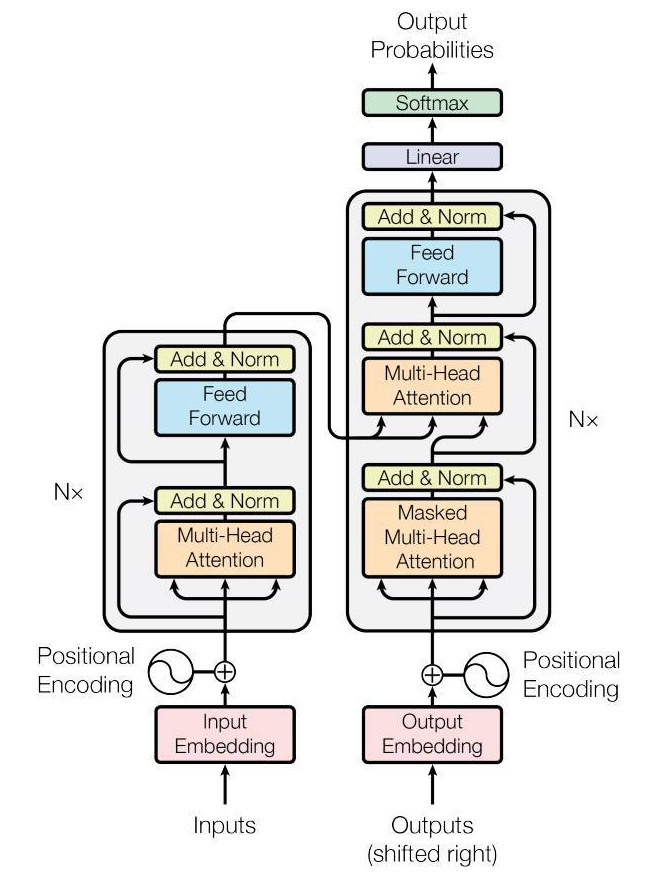

위 그림이 transformer 구조를 나타낸 그림이다.

왼쪽 부분이 input text를 처리하여 text의 embedding 표현을 생성하는 encoder이고, 오른쪽 부분이 한 번에 한 단어씩 번역된 text를 생성하는 decoder 부분이다.

왼쪽 입력으로는 프랑스 문장으로 번역하고 싶은 영어 문장이 완전히 입력되고, 오른쪽 입력으로는 그 영어 문장의 번역문 중 일부 문장이 입력도니다. 그럼 decoder는 이 오른쪽 입력과 encoder에서 생성한 embedding 표현을 사용하여 일부 번역 문장의 다음 단어를 생성하여 번역을 완성시킨다.

다시 말해 encoder module은 input text를 처리하여 입력의 문맥 정보를 포착하는 일련의 수치 표현(embedding vector)로 encodin한다.

decoder module에서는 encoding된 vector를 받아 출력 text를 생성한다.

encode와 decoder 모두 self-attention mechanism으로 연결된 많은 layer로 구성되어 있다. 이러한 mechanism으로 model은 sequence에 있는 서로 다른 token에 상대적인 가중치를 부여하여 어디에 집중할 지를 결정할 수 있다. 이렇게 집중하여 input text에서 긴 범위에 걸친 의존성과 맥락 관계를 포착할 수 있다.

이때 encoder와 decoder에 입력되는 문장은 그대로 입력되는 것이 아닌 전처리 과정을 거쳐서 숫치 표현으로 입력되야 한다.

#2장

pre-trained 단계에서 LLM은 next-word predict 작업을 수행하기 위해 text를 한 번에 한 token씩 처리한다.

이 장에서 배울 내용은 text를 token으로 분할하는 작업과 이러한 token을 vector 표현으로 어떻게 encoding하는지를 중점으로 배운다(tokenization을 배운다.).

text -> vector

위 과정을 embedding이라 부른다. 이 과정을 진행하는 model이 따로 있다(음성도 embedding할 수 있고, 영상도 embedding할 수 있지만 각각의 embedding model이 따로 필요하다.).

word embedding이 text embedding의 가장 일반적인 형태이지만 문장, 단락 혹은 문서 전체를 위한 embedding도 잇다. 문장이나 단락 embedding은 RAG에서 널리 사용된다.

초기 word embedding 중 가장 인기 있는 방법 중 하나는 Word2Vec이다.

이는 target word가 주어지면 문맥 단어를 예측하거나 그 반대의 방식으로 신경망을 훈련하여 word embedding을 생성한다. 즉 비슷한 맥락에 등장하는 단어는 비슷한 의미를 가지는 경향이 있다는 아이디어를 가지고 만들어진 algorithm이다.

그렇기에 이 algorithm으로 생성된 word embedding vector는 비슷한 단어 끼리는 가까이 분포되어 있고, 유사성이 없을 수록 두 vector 각이 벌어져 있다.

embedding model을 따로 사용해도 되지만 LLM은 일반적으로 입력층의 일부로 자체적인 embedding을 만들고 훈련 중에 업데이트한다.

LLM의 훈련의 일부로 embedding을 최적화하면 embedding을 특정 작업과 주어진 data에 최적화할 수 있다는 장점이 있다.

In [14]:
"""
이제 input text를 개별 token으로 분할하는 방법에 대해 알아보겠다.

일단 train에 사용할 data를 불러온다.
"""
import urllib.request
url=( "https://raw.githubusercontent.com/rickiepark/"
      "llm-from-scratch/main/ch02/01_main-chapter-code/"
      "the-verdict.txt")
file_path="the-verdict.txt"
urllib.request.urlretrieve(url,file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x79244a1dbb00>)

In [15]:
#the-verict.txt 파일을 로드한다.
with open("the-verdict.txt","r",encoding="utf-8") as f:
  raw_text = f.read()
print("파일의 총 문자 개수:",len(raw_text))
print("0번째 부터 98번째 문자를 출력:\n",raw_text[:99])

파일의 총 문자 개수: 20479
0번째 부터 98번째 문자를 출력:
 I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


이제 파일 내의 문자를 token화해보자. 이러한 과정을 tokenization라 하고, 이를 해주는 modle을 tokenizer라 한다.

다음으로는 text를 token list로 분할하는 과정을 살펴보겠다.

In [16]:
import re
text= "Hello, world. This, is a test."
result=re.split(r'(\s)',text)
print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [17]:
#위 결과로는 Hello,과 같이 단어와 쉼표가 함께 token으로 되어있었지만 다음 코드를 이용하여 이를 각각의 token으로 분할한다.
result=re.split(r'([,.]|\s)',text)
print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [18]:
#이제 token 리스트에 공백 또한 제거해보겠다.
result=[item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [19]:
#쉼표 이외의 특수 문자도 처리할 수 있도록 한다.
text="Hello, world. Is this-- a test?"
result=re.split(r'([,.:;?_!"()\']|--|\s)',text)
result=[item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


"Hello, world. Is this-- a test?" -> ['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']

위와 같이 간단한 tokenization을 보았다.

In [20]:
#이러한 과정을 소설 전체에 적용해 보겠다.
preprocessed=re.split(r'([,.:;?_!"()\']|--|\s)',raw_text)
preprocessed=[item.strip() for item in preprocessed if item.strip()]
print("공백을 제외한 text에 있는 token의 개수: ",len(preprocessed))
print("30개의 token 출력:\n",preprocessed[:30])

공백을 제외한 text에 있는 token의 개수:  4690
30개의 token 출력:
 ['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


다음으로 token을 정수 표현으로 바꿔 token ID을 만들어 보겠다.

이는 token ID를 embedding vector로 변환하기 전의 중간 단계이다.

일단 각 token을 특정한 token ID(정수값)로 mapping한 모음인 vocabulary을 먼저 구축해야 한다.

이러한 vocabulary는 training set 전체를 사용해 구축되며, training set에는 없던 새로운 text sample에도 이 vocabulary을 적용하여 tokenization하고 각 token을 token ID로 변환할 수 있다. 물론 새로운 text sample내 구축된 vocabulary내에는 없는 단어가 있다면 이 단어는 token으로 변환시킬 수 없다.

각 token이 고유한 token ID을 갖고 있기에 token ID만 있어도 이를 token으로 바꾸고 이 token을 합쳐 text로 바꿀 수 있다. 즉 역과정이 가능하다.


In [21]:
all_words=sorted(set(preprocessed))
vocab_size=len(all_words)
print(vocab_size)

1130


In [22]:
#vocabulary내 51개 항목을 출력한다(dictionary형태).
#결과에서도 볼 수 있듯이 알파벳 순으로 정렬되어 있으며, 각 token에는 이를 나타내는 고유한 정수값이 있다(index값).
vocab={token:integer for integer, token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
  print(item)
  if i>=50:
    break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


In [23]:
#text를 token으로 분할하고 vocabulary로 문자열과 정수의 mapping을 수행해 token ID를 생성하는 encode method,
#token ID를 text로 변환하기 위해 정수와 문자열의 mapping을 수행하는 decode method를 갖고 있는 class이다.
class SimpleTokenizerV1:
  def __init__(self,vocab):
    self.str_to_int=vocab #vocabulary를 class의 속성으로 저장하여 encode method와 decode method에서 참조할 수 있도록 함
    self.int_to_str={i:s for s,i in vocab.items()}  #token ID를 원본 text token으로 mapping하는 역vocabulary 생성

  def encode(self,text):
    preprocessed=re.split(r'([,.?_!"()\']|--|\s)',text)
    preprocessed=[item.strip() for item in preprocessed if item.strip()]
    ids=[self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self,ids):
    text=" ".join([self.int_to_str[i] for i in ids])  #ids를 가지고 token을 text로 되돌림
    text=re.sub(r'\s+([,.?!"()\'])',r'\1',text)
    return text

In [24]:
#위 class로 새로운 tokenizer object를 만들고 소설의 한 구절을 tokenization하겠다.
tokenizer=SimpleTokenizerV1(vocab)  #object 생성
text= """"It's the last he painted, you know,"
      Mrs. Gisburn said with pardonable pride."""

#text가 가리키는 문자열을 object내 encode method를 이용하여 각 token을 미리 구축된 vocabulary을 참고하여 token ID로 변환
ids=tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [25]:
#decode method로 이 token ID를 다시 text로 바꾼다.
print(tokenizer.decode(ids))

" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


In [26]:
#training set에 없는 새로운 text sample을 적용해 보겠다.
text="hello, do you like tea?"
print(tokenizer.encode(text))

KeyError: 'hello'

vocabulary를 구축하는데 사용한 training set에는 hello라는 단어가 없었기 때문에 당연히 구축된 vocabulary에도 hello라는 token이 없다.

그렇기에 hello라는 단어를 구축된 vocabulary를 사용하여 token ID로 변환할려고 하면 오류가 발생한다.

이렇게 구축된 vocabulary에는 없는 단어를 처리하기 위해서는 tokenizer를 수정해야 한다.

-> model(=tokenizer)가 text로부터 문맥이나 그 밖의 관련된 정보를 잘 이해할 수 있도록 특수 문맥 token을 추가해야한다.

In [27]:
#tokenizer가 vocabulary에 없는 단어를 만났을 때 <|unk|>라는 token을 사용하도록 한다.
#또한 관련이 없는 text 사이에 <|endoftext|>라는 token을 추가한다. 이 token을 사용하여 연결되어 있지만 서로 관련이 없음을 LLM에게 알려준다.
#일단 이러한 두 token을 vocabulary내에 추가한다.
print("vocabulary 길이: ",len(vocab.items()))
all_tokens=sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>","<|unk|>"])
vocab={token:integer for integer, token in enumerate(all_tokens)}

print("vocabulary 길이: ",len(vocab.items()))

vocabulary 길이:  1130
vocabulary 길이:  1132


In [28]:
for i, item in enumerate(list(vocab.items())[-5:]):
  print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [30]:
#다음은 위에서 구현한 tokenizer를 개선하여
#알지 못하는 단어 또한 처리하도록 하는 tokenizer를 구현하였다.
class SimpleTokenizerV2:
  def __init__(self,vocab):
    self.str_to_int=vocab
    self.int_to_str={i:s for s,i in vocab.items()}

  def encode(self,text):
    preprocessed=re.split(r'([,.:;?_!"()\']|--|\s)',text)
    preprocessed=[item.strip() for item in preprocessed if item.strip()]
    #알지 못하는 단어를 <|unk|>라는 token으로 변환한다.
    preprocessed=[item if item in self.str_to_int
                      else "<|unk|>" for item in preprocessed ]
    ids=[self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self,ids):
    text=" ".join([self.int_to_str[i] for i in ids])
    text=re.sub(r'\s+([,.:;?!"()\'])',r'\1',text)
    return text

In [31]:
#서로 관련이 없는 2개의 독립된 문장을 연결한다. 굳이 tokenizer를 사용하지는 않음
text1="Hello, do you like tea?"
text2="In the sunlit terraces of the palace."
text=" <|endoftext|> ".join((text1,text2))
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [32]:
#위에서 연결한 text를 개선된 tokenizer를 사용하여 token ID을 출력하겠다.
#위에서 보면 알 수 있듯이 1131라는 token ID는 알지 못하는 단어에 대한 token ID이다.
tokenizer=SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]


In [33]:
print(tokenizer.decode(tokenizer.encode(text)))
#결과를 보면 Hello와 palace가 구축된 vocabulary에는 없는 token이라는 것을 알 수 있다.

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


GPT에서 사용하는 tokenizer는 vocabulary에 없는 단어를 위한 <|unk|> token은 사용하지 않는다.

다음으로는 GPT모델에서 사용하는 단어를 subword로 분할하는 byte-pair encoding라는 tokenizer에 대해 살펴보겠다.

In [34]:
#tiktoken라는 library를 사용하여 BPE tokenizer를 구현하겠다.
!pip install tiktoken

In [35]:
from importlib.metadata import version
import tiktoken
print("tiktoken 버전:", version("tiktoken"))

tiktoken 버전: 0.12.0


In [36]:
#BPE tokenizer 초기화
tokenizer=tiktoken.get_encoding("gpt2")

In [37]:
#이 tokenizer 사용도 SimpleTokenizerV2의 encode method 사용법과 비슷하다.
text=(
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    " of someunknownPlace."
)
integers=tokenizer.encode(text,allowed_special={"<|endoftext|>"})
print("text에 대한 token ID출력: \n",integers)

text에 대한 token ID출력: 
 [15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 617, 34680, 27271, 13]


In [38]:
#token ID를 원래 text로 되돌린다.
strings=tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace.


이 BPE tokenizer는 someunknownPlace와 같은 vocabulary에 없는 단어 또한 정확하게 encoding하고 decoding할 수 있다. 다만 <|unk|> token은 사용하지 않는다.

BPE algorithm은 vocabulary에 없는 단어를 더 작은 subword, 심지어 개별 문자로 나누어 처음 본 단어를 처리한다. 이 덕에 tokenization 과정에서 처음 보는 단어를 만나더라도 subword token이나 문자의 sequence로 표현할 수 있다.


In [39]:
strings=tokenizer.decode([617,34680, 27271])
print(strings)

print("--------------")
print(tokenizer.decode([617]))
print(tokenizer.decode([34680]))
print(tokenizer.decode([27271]))

 someunknownPlace
--------------
 some
unknown
Place


위 결과와 같이 someunknownPlace와 같이 알지 못하는 한 단어를 vocabulary내에 있는 token으로 세분화해서 encoding하여 tokenization을 한다.

    someunknownPlace -> |some|unknown|Place|
          token ID      | 617| 34680 |27271|  

In [40]:
#BPE tokenizer로 vocabulary내에 없는 단어인 Akwirw ier에 대해서도 tokenization을 해보겠다.
text="Akwirw ier"
integers=tokenizer.encode(text)
print(integers)
print("---------\n")
print("각 token ID에 대한 token: ")
for i in integers:
  print(f"{i} ->",tokenizer.decode([i]))
print("--------\n")
print(tokenizer.decode(integers))

[33901, 86, 343, 86, 220, 959]
---------

각 token ID에 대한 token: 
33901 -> Ak
86 -> w
343 -> ir
86 -> w
220 ->  
959 -> ier
--------

Akwirw ier


BPE는 vocabulary를 구축하는 과정에서 vocabulary내에 있고 반복적으로 자주 등장하는 문자를 subword로 합치고, 다시 자주 등장하는 subword를 단어로 합쳐서 vocabulary를 구축하는 방식이다.

In [41]:
#위에서 언급했듯이 LLM은 text에 있는 다음 단어를 예측하는 식으로 pre-trained하기에 다음에 오는 token이 일종의 label 역할을 한다(현재까지의 token들만 보고 다음 token을 예측하기 때문).
#다음으로는 sliding window을 사용하여 training dataset에서 input-target 쌍을 추출하는 data loader를 구현해보겠다.
#먼저 tokenization이다.
with open("the-verdict.txt","r",encoding="utf-8") as f:
  raw_text = f.read()

enc_text=tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [42]:
#처음 50개 token 삭제, 안해도 상관없다.
enc_sample=enc_text[50:]

In [43]:
#input-target 쌍을 만들자.
#input token을 담은 x와 input에서 token 하나만큼 이동한 target을 담은 y변수를 만든다.
context_size=4  #얼마나 많은 token을 포함할지 결정
x=enc_sample[:context_size]
y=enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [44]:
#input과 input에서 token 하나만큼 이동시킨 target을 사용하여 next word predict 작업을 수행한다.
#밑의 코드는 실제로 next word predict작업을 하는 코드는 아니고, 현재까지의 token으로 어떤 token을 예측할지를 보여주는 코드이다.
#화살표 왼쪽의 값인 context가 LLM이 받을 입력이고, 오른쪽이 예측해야 할 target token ID이다.
for i in range(1,context_size+1):
  context=enc_sample[:i]
  desired=enc_sample[i]
  print(context,"---->",desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [45]:
for i in range(1,context_size+1):
  context=enc_sample[:i]
  desired=enc_sample[i]
  print(tokenizer.decode(context),"---->",tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


In [46]:
#input dataset을 순회하면서 pytorch tensor로 input과 target을 반환하는 효율적인 dataloader를 구현한다.
#LLM이 사용할 text를 담은 input tensor와 LLM이 예측해야 할 target을 담은 target tensor을 생성한다.
import torch
from torch.utils.data import Dataset,DataLoader

#pytorch Dataset class를 기반으로 dataset에서 개별 행을 추출한다.
#각 행은 input_chunk tensor에 할당된, 즉 max_length만큼 여러 개의 token ID로 구성된다.
#target_chunk tensor는 각 행에 상응하는 target을 가지고 있다.
class GPTDatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_length,stride):
    self.input_ids=[]
    self.target_ids=[]

    token_ids=tokenizer.encode(txt) #전체 text를 tokenization한다.

    #sliding window를 사용해 data를 max_length 길이의 중첩된 sequence로 나눈다.
    for i in range(0,len(token_ids)-max_length,stride):
      input_chunk=token_ids[i:i+max_length]
      target_chunk=token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):  #dataset에 있는 전체 row 수를 반환
    return len(self.input_ids)

  def __getitem__(self,idx):  #dataset에서 하나의 row를 반환한다.
    return self.input_ids[idx],self.target_ids[idx]

In [47]:
#input-target 쌍의 batch를 생성하기 위한 dataloader
def create_dataloader_v1(txt,batch_size=4,max_length=256,
                         stride=128,shuffle=True,drop_last=True,
                         num_workers=0):
  #tokenizer 초기화
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=GPTDatasetV1(txt,tokenizer,max_length,stride) #dataset 생성
  dataloader=DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last,
      num_workers=num_workers
  )
  return dataloader

In [48]:
#문맥 크기를 4와 batch size를 1로 dataloader를 테스트 해보겠다.
with open("the-verdict.txt","r",encoding="utf-8") as f:
  raw_text=f.read()

dataloader=create_dataloader_v1(
    raw_text,batch_size=1,max_length=4,stride=1,shuffle=False
)
data_iter=iter(dataloader)
first_batch=next(data_iter)
print(first_batch)
#첫 번재 tensor는 input token ID를 저장하고 있고, 두 번째 tensor는 target token ID를 저장하고 있다.
#max_length가 4이므로 두 tensor는 각각 4개의 token ID를 갖고 있다.
#일반적으로 LLM을 훈련할 때는 적어도 256 크기의 입력을 사용해야 한다.

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [49]:
second_batch=next(data_iter)
print(first_batch)
print(second_batch)
#second_batch는 first_batch에 비해 한 token씩 왼쪽으로 밀려있다.
#이는 stride 매개변수 값이 1이기 때문이다.
#input dataset에서 여러 batch를 만들 때 input window로 text 위를 sliding하는데, 이때 stride 매개변수가 얼마만큼 sliding할 지를 결정한다.

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


In [50]:
#max_length가 2이고, stride가 2일 때
dataloader=create_dataloader_v1(
    raw_text,batch_size=1,max_length=2,stride=2,shuffle=False
)
data_iter=iter(dataloader)
first_batch=next(data_iter)
print(first_batch)
second_batch=next(data_iter)
print(second_batch)

[tensor([[ 40, 367]]), tensor([[ 367, 2885]])]
[tensor([[2885, 1464]]), tensor([[1464, 1807]])]


In [51]:
#max_length가 8이고, stride가 2일 때
dataloader=create_dataloader_v1(
    raw_text,batch_size=1,max_length=8,stride=2,shuffle=False
)
data_iter=iter(dataloader)
first_batch=next(data_iter)
print(first_batch)
second_batch=next(data_iter)
print(second_batch)

[tensor([[  40,  367, 2885, 1464, 1807, 3619,  402,  271]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899]])]
[tensor([[ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138]]), tensor([[ 1464,  1807,  3619,   402,   271, 10899,  2138,   257]])]


In [52]:
dataloader=create_dataloader_v1(
    raw_text,batch_size=8,max_length=4,stride=4,shuffle=False
)

data_iter=iter(dataloader)
inputs,targets=next(data_iter)
print("입력:\n",inputs)
print("\n타깃:\n",targets)

입력:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

타깃:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


이제 LLM 훈련을 위한 input text 준비의 마지막 단계이다.

token ID를 embedding vector로 변환하는 것이다.

이를 위해서는 먼저 embedding vector를 랜덤한 값으로 초기화한다.

지금까지는 token ID만 가지고 encoding과 decoding을 했다면 이제부터는 embedding vector를 가지고 encoding과 decoding을 하겠다.

    LLM 훈련을 위한 input text 준비의 전반적인 과정
      text를 token 단위로 쪼갬(tokenization) -> text token을 token ID로 변환 -> token ID를 embedding vector로 변환
        |----BPE과 같은 tokenization algorithm 사용하여 vocabulary구축----|      |심층 신경망을 사용해 embedding을 한다|

In [53]:
#token ID -> embedding vector
#4개의 입력 token이 있다고 가정
input_ids=torch.tensor([2,3,5,1])

In [54]:
#vocabulary size가 6이고, 크기가 3인 embedding을 만들겠다.
vocab_size=6
output_dim=3

In [55]:
#vocab_size와 output_dim을 사용해 pytorch의 embedding layer 초기화
torch.manual_seed(123)
embedding_layer=torch.nn.Embedding(vocab_size,output_dim)
print(embedding_layer.weight)
#이 결과와 같이 embedding layer의 weight matrix는 작고 랜덤한 값을 담고 있다. 이 값은 LLM 최적화의 일부로 LLM 훈련 과정에서 최적화된다.
#weight matrix의 행이 6개라는 것은 vocabulary에 있는 6개의 token 각각에 하나의 행이 할당되었다는 것을 의미하고,
#weight matrix의 열이 3개라는 것은 embedding dimension이 3이라는 의미한다.

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [56]:
#이 weight matrix를 token ID에 적용하여 embedding vector를 얻겠다.
print(embedding_layer(torch.tensor([3])))
#반환된 값이 token ID 3에 대한 embedding vector이다.
#이는 weight matrix의 4번째 행과 같은데, 이로써 embedding layer는 token ID를 기반으로 weight matrix에서 행을 추출하는 검색 연산을 수행한다는 것을 알 수 있다.
#여기서 설명한 embedding layer는 본질적으로 one-hot encoding 다음에 fully connected layer(activation function과 bias가 없는)를 두어 행렬곱을 수행하는 것보다 효율적인 방법이다.

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [57]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


다음으로는 token의 위치 정보를 encoding하겠다.

왜냐, self-attention mechaninsm에는 sequence내의 token 위치 혹은 순서에 대한 개념이 없기 때문이다. 그래서 LLM에 위치 정보 또한 줘야 한다.

이를 위해 크게 두 종류의 위치를 고려한 embedding을 사용할 수 있다.

    상대 위치 임베딩: token의 상대적인 위치 또는 token 사이의 거리를 강조한다.
                    즉 멀리 떨어져 있는 정도를 바탕으로 vector들의 관계를 학습한다.

    절대 위치 임베딩: sequence의 특정 위치에 직접 연관된다.
                    입력 sequence의 각 위치에 대해 고유한 embedding이 token embedding에 더해져 정확한 위치 정보를 추가하여,
                    LLM을 위한 입력 embedding을 생성한다.


In [61]:
#GPT 모델은 transformer model의 위치 embedding과 같이 고정되거나, 사전에 정의된 embedding이 아닌 model의 훈련 과정에서 최적화되는 절대 위치 embedding을 사용한다.
vocab_size=50257
output_dim=256
token_embedding_layer=torch.nn.Embedding(vocab_size,output_dim) #50257개의 각각의 token ID을 256차원의 vector로 embedding하였다.
print(torch.nn.Embedding(vocab_size,output_dim))

Embedding(50257, 256)


In [63]:
max_length=4
dataloader=create_dataloader_v1(
    raw_text,batch_size=8,max_length=max_length,stride=max_length,shuffle=False
)
data_iter=iter(dataloader)
inputs,targets=next(data_iter)
print("토큰 ID:\n",inputs)
print("\n입력 크기:\n",inputs.shape)  #token ID tensor의 차원이 8 x 4면, batch에 4개의 token을 가진 text sample 8개가 들어 있다는 의미이다.

토큰 ID:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

입력 크기:
 torch.Size([8, 4])


In [64]:
token_embeddings=token_embedding_layer(inputs)  #8 x 4 x 256차원의 tensor는 각 token ID가 256차원 vector로 embedding되었다는 것을 보여준다.
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [65]:
#token_embedding_layer와 동일한 embedding 차원을 갖는 또다른 embedding layer를 만든다(position embedding layer 생성).
context_length=max_length
pos_embedding_layer=torch.nn.Embedding(context_length,output_dim)
pos_embedding=pos_embedding_layer(torch.arange(context_length)) #torch.arange(context_length)은 숫자 0~최대 입력 길이-1 범위의 sequence를 담고 있는 vector이다.
                                                                #context_length가 LLM이 지원하는 입력 크기를 나타내는 변수이다.
print(pos_embedding.shape)  #position embedding vector는 4개의 256 차원 vector로 구성된다.

torch.Size([4, 256])


In [66]:
input_embeddings=token_embeddings+pos_embedding
print(input_embeddings.shape)

torch.Size([8, 4, 256])


#요약
LLM은 text를 가지고 훈련한다. 이때 LLM의 훈련 과정은 두 단계로 나뉜다.

1. 대량의 label이 없는 corpus들을 가지고 next-word predict작업을 통해 학습하는 pre-trained 과정
2. 특정 주제에 대한 label이 있는 corpus들을 가지고 학습을 진행하는 fine-tuning과정

LLM은 pre-trained 과정을 거처 어느정도 말을 이해할 수 있도록 학습되고, fine-tuning과정을 거쳐 전문적으로 특화된 작업을 할 수 있도록 학습된다.

방금 말했듯이 LLM을 학습하기 위해서는 text들이 필요한다. LLM은 결국 숫자 연산을 통해 작업을 수행하기 때문에 사람이 이해하는 자연어 형태로는 LLM에 입력할 수 없다. 그렇기에 text를 숫자로 변환시켜주는 전처리 과정이 우선적으로 필요하다.

전처리 과정은 다음과 같다.

    tokenizer를 사용하여 vocabulary를 구축한다. 이때까지는 굳이 인공신경망을 사용하지 않는다.
    vocabulary가 구축되었다면 각 token을 vector형태로 변환해주는 embedding과정을 거친다.
    이러한 embedding 과정을 거쳐 각 token에 대한 embedding vector을 구하면 token 사이의 관계 또한 알 수 있다.
    embedding layer는 인공신경망을 사용하여 구현한다.
    embedding layer는 두 단계를 거친다. token embedding과 position embedding이다.
    token embedding은 말 그대로 token을 임의의 vector로 변환하는 것을 의미하고,
    position embedding은 sequence내에 token들이 특정 위치에 분포되어 있을 텐데 이러한 위치에 대한 정보를 나타내는 vector이다.
    position embedding의 종류는 두 가지로 나뉘고, GPT에서는 model의 훈련 과정에서 최적화되는 절대 위치 임베딩을 사용한다.
    이후 embedding layer에서 최종적으로 출력되는 vector가 LLM의 입력이 된다.